# Imports and Preprocessing

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

analysis_dir = "/accounts/projects/jchayes/commnotes/commnotes-analysis/analysis"
os.chdir(analysis_dir)
sys.path.insert(0, analysis_dir)

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from scipy.stats import spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess

import statsmodels.formula.api as smf
import statsmodels.api as sm

from src.data_loader import *
from src.analysis import *
from src.utils import *

from src.visualization import *
from src.visualization import (
    apply_publication_style,
    _setup_ax,
    _finalize,
    _C_BLUE,
    _C_ORANGE,
    _C_EVENT,
    _C_ZERO,
    _C_LIGHT,
    _C_PURPLE,
    _C_AMBER,
    _MUTED_PALETTE,
    _FONT_LEGEND,
    _FONT_ANNOT,
    _FONT_TICK,
    _FONT_LABEL
)

In [4]:
# --- Configuration (Corrected Paths) ---
# Using the absolute paths from your working environment
NOTES_PATH = "/scratch/users/commnotes/communitynotes/sourcecode/notes-00000.tsv"
HISTORY_PATH = "/scratch/users/commnotes/communitynotes/sourcecode/noteStatusHistory-00000.tsv"
RATINGS_DIR = "/scratch/users/commnotes/communitynotes/sourcecode/ratings"
WEEKLY_OUTPUTS_PATH = "/scratch/users/commnotes/communitynotes2022/communitynotes/static/sourcecode/weekly_outputs"
WEEKLY_OUTPUTS_PATH_2025 = "/scratch/users/commnotes/communitynotes/sourcecode/weekly_outputs"


max_date = "2023-06-01"

In [5]:
print("--- Loading and Preparing Data ---")
# This DataFrame contains data related to "notes" associated with tweets. It includes unique IDs for notes, authors, and tweets, along with
# timestamps, classifications (e.g., "MISINFORMED_OR_POTENTIALLY_MISLEADING"), and other
# attributes describing the history of the notes
notes_df = pd.read_csv(NOTES_PATH, sep='\\t', dtype={'noteAuthorParticipantId': str, 'tweetId': str, 'noteId': str})
notes_df["noteId"]=notes_df["noteId"].astype(int)

# The following is all note ratings published by X keeping the following columns: 
# "'noteId', 'raterParticipantId', 'createdAtMillis', 'helpfulnessLevel'" since we don't use the rest.
ratings_df = read_ratings_from_directory(RATINGS_DIR, start_date_str="2022-06-01",end_date_str=max_date)

# The following df is the results of the matrix factorization for both 2022 and 2025 version of the code.
note_df_full, rater_df, status_df, helpfulness_df, aux_df = load_weekly_outputs(WEEKLY_OUTPUTS_PATH,debug=False)
note_df_full_2025, rater_df_2025, status_df_2025, helpfulness_df_2025, aux_df_2025 = load_weekly_outputs(WEEKLY_OUTPUTS_PATH_2025,debug=False)

# This df is the history of all notes
history_df =   pd.read_csv(HISTORY_PATH, sep='\\t', dtype={'noteAuthorParticipantId': str, 'tweetId': str, 'noteId': str})

# The following df is notes with corresponding topics. Topics are modelled by the X topic modeling algorithm.
notes_df_topic = pd.read_csv("/accounts/projects/jchayes/commnotes/df_notes_with_topics.csv")

# The following df is notes with corresponding topics based on LLM topic modelers.
notes_df_llms = pd.read_csv("/accounts/projects/jchayes/commnotes/notes_llm_topic.csv")


notes_df_topic['noteId'] = notes_df_topic['noteId'].astype(int)

--- Loading and Preparing Data ---


/tmp/ipykernel_1110240/3667858762.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


Found 16 total rating files. Processing them in chunks to filter by date.


Loading weekly outputs: 100%|██████████| 84/84 [02:12<00:00,  1.58s/it]


note is loaded.
rater is loaded.
status is loaded.
helpfulness is loaded.
aux is loaded.


Loading weekly outputs: 100%|██████████| 44/44 [00:03<00:00, 13.78it/s]
/tmp/ipykernel_1110240/3667858762.py:17: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


note is loaded.
rater is loaded.
status is loaded.
key without data status
helpfulness is loaded.
key without data helpfulness
aux is loaded.
key without data aux


In [6]:
ratings_df['createdAtDate'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms')

In [7]:
rater_df_2025 = rater_df_2025.rename(columns={"internalRaterFactor1": "raterFactor1", "internalRaterIntercept": "raterIntercept"})
note_df_full_2025 = note_df_full_2025.rename(columns={"internalNoteFactor1": "noteFactor1", "internalNoteIntercept": "noteIntercept"})

In [8]:
rollout_date = pd.to_datetime("2022-10-01")

In [9]:
# get one cohort of legacy raters who were active before rollout date
legacy_users = ratings_df[ratings_df['createdAtDate'] < rollout_date]['raterParticipantId'].unique()

# get one cohort of new raters who joined between Oct. 2022 and Jan. 2023
new_users = ratings_df[(ratings_df['createdAtDate'] >= rollout_date) & (ratings_df['createdAtDate'] < pd.to_datetime("2023-01-01"))]['raterParticipantId'].unique()
new_users = [user for user in new_users if user not in legacy_users]

In [10]:
len(legacy_users), len(new_users)

(1202, 7177)

# Main Text Figure 1

## Figure 1(a)


--- Slide 8 & 9: Factor Distribution Shifts ---


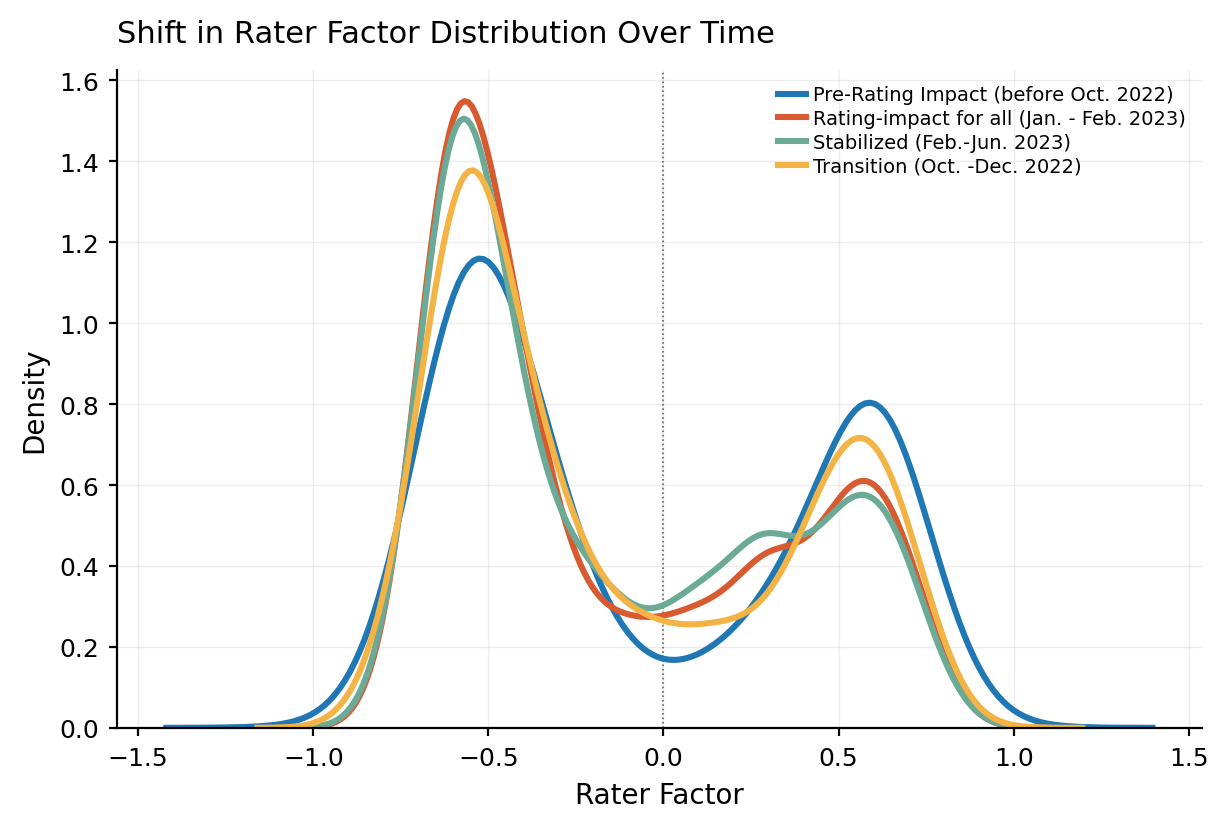

In [12]:
# Prepare common dataframes
latest_rater_factors = rater_df.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
latest_note_factors = note_df_full.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
rater_df['month_str'] = rater_df['week_dt'].dt.strftime('%Y-%m')
rater_df['phase'] = rater_df['month_str'].apply(assign_phase)

# Save the plot to /accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main
plot_factor_distribution_shifts(rater_df, 'raterFactor1', save_path='/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/rater_factor_distribution_shift_2022.png')


## Figure 1(b)

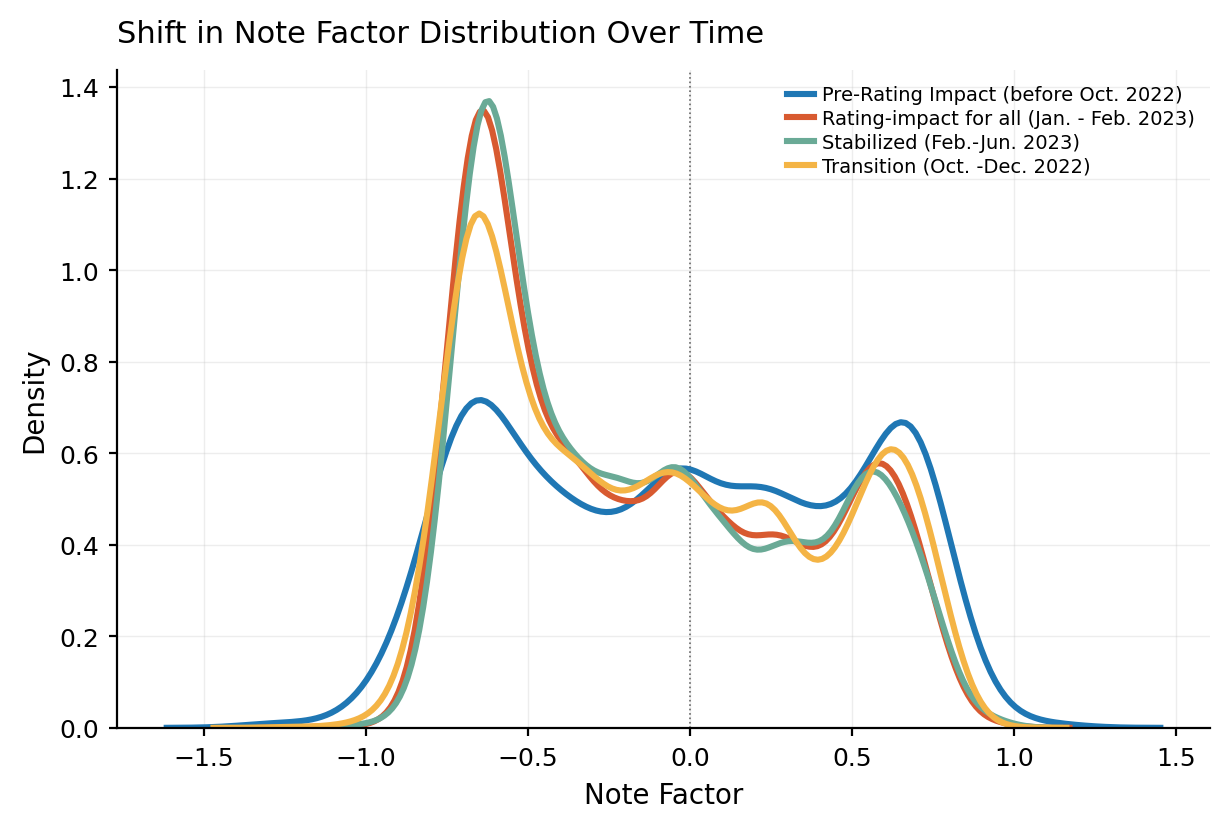

In [13]:
note_df_full['month_str'] = note_df_full['week_dt'].dt.strftime('%Y-%m')
note_df_full['phase'] = note_df_full['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(note_df_full, 'noteFactor1', save_path='/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/note_factor_distribution_shift_2022.png')

# Main Text Figure 2

In [14]:
def prepare_rating_factors_over_time_weekly(ratings_df, note_df, rater_df):
    # Add week column to ratings
    rater_df['week_dt'] = pd.to_datetime(rater_df['week_dt']).dt.normalize()
    note_df['week_dt'] = pd.to_datetime(note_df['week_dt']).dt.normalize()
    ratings_df['week_dt'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms').dt.to_period('W').dt.start_time

    
    # Ensure note_df and rater_df also have 'week' column
    if 'week_dt' not in note_df.columns or 'week_dt' not in rater_df.columns:
        raise ValueError("note_df and rater_df must include a 'week' column for weekly merging.")
    
    ratings_df = ratings_df.sort_values(['week_dt'])
    note_df = note_df.sort_values([ 'week_dt'])
    rater_df = rater_df.sort_values(["week_dt"])

    # Merge_asof for note factors
    df = pd.merge_asof(
        ratings_df,
        note_df[['noteId', 'noteFactor1', 'noteIntercept', 'week_dt']],
        by='noteId',
        left_on='week_dt',
        right_on='week_dt',
        direction='backward',
        allow_exact_matches=False
    )

    # Ensure participant IDs are the same type (string is usually safest)
    rater_df["raterParticipantId"] = rater_df["raterParticipantId"].astype(str)
    df["raterParticipantId"] = df["raterParticipantId"].astype(str)
    
    # Merge with rater factors by raterParticipantId and week
    df = pd.merge_asof(
        left=df,
        right=rater_df[["raterParticipantId", "week_dt", "raterFactor1", 'raterIntercept']],
        by="raterParticipantId",
        left_on="week_dt",
        right_on="week_dt",
        direction="backward",
        allow_exact_matches=False
    )

    # Convert labels
    df['helpful_binary'] = np.where(
        df['helpfulnessLevel'] == 'HELPFUL', 1,
        np.where(df['helpfulnessLevel'] == 'NOT_HELPFUL', 0, np.nan)
    )

    # # Clean up
    df = df.dropna(subset=['noteFactor1', 'raterFactor1', 'helpful_binary'])

    # Label for coloring
    df['vote_label'] = df['helpful_binary'].map({1: 'Helpful', 0: 'Not Helpful'})

    return df


# Prepare data
df_plot = prepare_rating_factors_over_time_weekly(ratings_df, note_df_full_2025, rater_df_2025)

In [15]:
start = '2022-08-01'
end = '2023-01-01'

cutoff = '2022-10-01'

df_plot['week_dt'] = pd.to_datetime(df_plot['week_dt'])
df_plot = df_plot[(df_plot['week_dt'] >= start) & (df_plot['week_dt'] <= end)]
df_plot['dot_product'] = df_plot["noteFactor1"] * df_plot["raterFactor1"]
df_plot_legacy = df_plot[df_plot['raterParticipantId'].isin(legacy_users)]

Corr before: 0.7921
Corr after: 0.5251
Observed diff: -0.2670
P-value: 0.0100


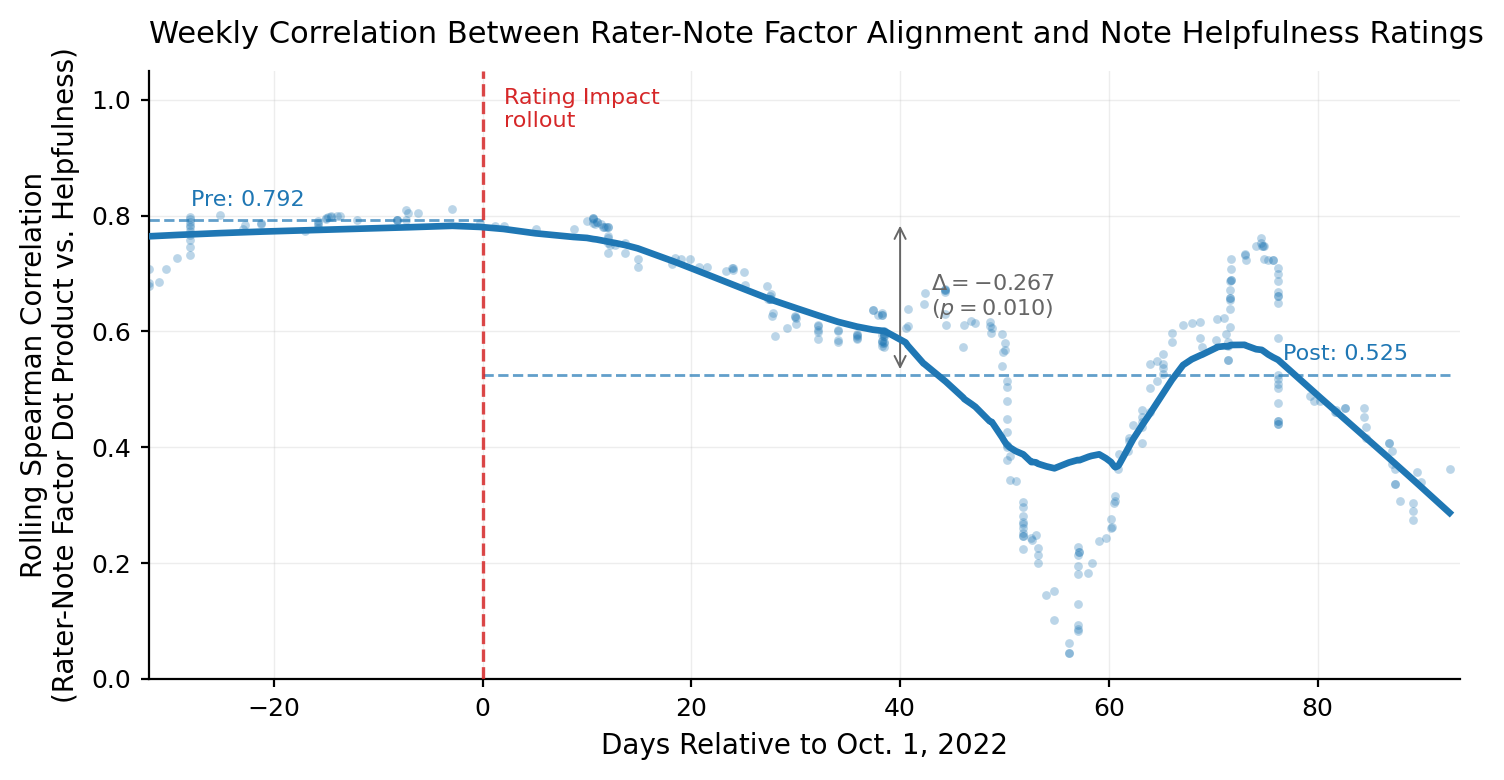

In [67]:
# Use the actual rating timestamp (not the week bucket) so points spread over time.
df_plot_legacy = df_plot_legacy.copy()
df_plot_legacy["rating_dt"] = pd.to_datetime(df_plot_legacy["createdAtMillis"], unit="ms")
df_plot_legacy = df_plot_legacy.sort_values("rating_dt").reset_index(drop=True)

# Compute the average spearman r between notehelpfulness and the dot product of rater factor * note factor
before = df_plot_legacy[df_plot_legacy['week_dt'] < cutoff]
after = df_plot_legacy[df_plot_legacy['week_dt'] > cutoff]

corr_before = spearmanr(before['dot_product'], before['helpful_binary']).correlation
corr_after = spearmanr(after['dot_product'], after['helpful_binary']).correlation
observed_diff = corr_after - corr_before
print(f'Corr before: {corr_before:.4f}')
print(f'Corr after: {corr_after:.4f}')
print(f'Observed diff: {observed_diff:.4f}')

# Do a permutation test to compute a p-value
all_data = pd.concat([before, after]).reset_index(drop=True)
n_before = len(before)
perm_diffs = []

for _ in range(1000):
    shuffled = all_data.sample(frac=1).reset_index(drop=True)
    perm_before = shuffled.iloc[:n_before]
    perm_after = shuffled.iloc[n_before:]

    c_before = spearmanr(perm_before['dot_product'], perm_before['helpful_binary']).correlation
    c_after = spearmanr(perm_after['dot_product'], perm_after['helpful_binary']).correlation
    perm_diffs.append(c_after - c_before)

perm_diffs = np.array(perm_diffs)
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f'P-value: {p_value:.4f}')



# plot rolling spearman
window = 50
min_periods = 20
rolling_spearman = []

for i in range(len(df_plot_legacy)):
    start_i = max(0, i - window)
    window_data = df_plot_legacy.iloc[start_i:i + 1]

    if len(window_data) < min_periods:
        rolling_spearman.append(np.nan)
    else:
        corr, _ = spearmanr(
            window_data["dot_product"],
            window_data["helpful_binary"],
        )
        rolling_spearman.append(corr)

df_plot_legacy["rolling_corr"] = rolling_spearman
df_plot_legacy["rolling_corr"] = df_plot_legacy["rolling_corr"].clip(-1, 1)

cutoff_dt = pd.to_datetime(cutoff)
# Continuous days (with fractional part) relative to cutoff, so x-positions vary within a week.
df_plot_legacy["days_rel"] = (
    (df_plot_legacy["rating_dt"] - cutoff_dt).dt.total_seconds() / 86400.0
)
valid = df_plot_legacy.dropna(subset=["rolling_corr", "days_rel"]).copy()

smoothed = lowess(
    valid["rolling_corr"].to_numpy(),
    valid["days_rel"].to_numpy(),
    frac=0.3,
    return_sorted=True,
)

pre_mean = corr_before
post_mean = corr_after
delta = observed_diff

apply_publication_style()
fig, ax = plt.subplots(figsize=(7.5, 4.0))

ax.scatter(
    valid["days_rel"],
    valid["rolling_corr"],
    color=_C_BLUE,
    alpha=0.30,
    s=10,
    linewidths=0,
    zorder=2,
)
ax.plot(smoothed[:, 0], smoothed[:, 1], color=_C_BLUE, linewidth=2.4, zorder=4)
ax.axvline(0, color=_C_EVENT, linewidth=1.2, linestyle="--", alpha=0.85, zorder=3)
ax.axhline(0, color=_C_ZERO, linewidth=0.5, linestyle=":", zorder=1)

ax.hlines(pre_mean, valid["days_rel"].min(), 0, color=_C_BLUE, linewidth=1.0, linestyle="--", alpha=0.7)
ax.hlines(post_mean, 0, valid["days_rel"].max(), color=_C_BLUE, linewidth=1.0, linestyle="--", alpha=0.7)

ax.text(valid["days_rel"].min() + 4, pre_mean + 0.025, f"Pre: {pre_mean:.3f}", fontsize=_FONT_ANNOT, color=_C_BLUE)
ax.text(valid["days_rel"].max() - 4, post_mean + 0.025, f"Post: {post_mean:.3f}", fontsize=_FONT_ANNOT, color=_C_BLUE, ha="right")

arrow_x = min(40, valid["days_rel"].max() - 5)
ax.annotate(
    "",
    xy=(arrow_x, post_mean),
    xytext=(arrow_x, pre_mean),
    arrowprops=dict(arrowstyle="<->", color=_C_ZERO, linewidth=0.7),
)
ax.text(
    arrow_x + 3,
    (pre_mean + post_mean) / 2,
    f"$\\Delta = {delta:.3f}$\n$(p = {p_value:.3f})$",
    color=_C_ZERO,
    fontsize=_FONT_ANNOT,
    ha="left",
    va="center",
)

ax.text(2, 1.02, "Rating Impact\nrollout", color=_C_EVENT, fontsize=_FONT_ANNOT, va="top")
ax.set_xlim(valid["days_rel"].min(), valid["days_rel"].max() + 1)
ax.set_ylim(0, 1.05)

_setup_ax(ax)
_finalize(
    fig,
    ax,
    xlabel="Days Relative to Oct. 1, 2022",
    ylabel="Rolling Spearman Correlation\n(Rater-Note Factor Dot Product vs. Helpfulness)",
    title="Weekly Correlation Between Rater-Note Factor Alignment and Note Helpfulness Ratings",
    save_path="/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/spearman-correlation-visualization.png",
)


# Main Text Figure 3

In [22]:
history_df["noteId"]=history_df["noteId"].astype(int)

CONTROVERSIAL_TOPICS = [
    'USPolitics', 'UkraineConflict', 'GazaConflict',
    'CrimeLegal', 'HealthCovid', 'EconomyFinance','MessiRonaldo',  'politics', 'economy', 'health'
]

NON_CONTROVERSIAL_TOPICS = [
    'SpaceAstronomy', 'ClimateEnvironment', 'EntertainmentMoviesTV',
    'WeatherDisasters', 'TechCompanies', 'SportsNFL', 'SportsNBA',
'FoodNutrition', 'Education', 'Scams',
    'ArtificialIntelligence', 'science', 'other'
]

notes_df_topic["controversial"] = np.select(
    [
        notes_df_topic['noteTopic'].isin(CONTROVERSIAL_TOPICS),
        notes_df_topic['noteTopic'].isin(NON_CONTROVERSIAL_TOPICS),
    ],
    ["Controversial", "Non-Controversial"],
    default=pd.NA,
)

In [23]:
# Proportion of controversial vs. non-controversial BOW/X-topic-labeled NEW notes
# from June 1, 2022 through June 1, 2023

START_DATE = "2022-06-01"
END_DATE = "2023-06-01"

bow_notes_window = notes_df_topic.copy()
bow_notes_window["createdAtDate"] = pd.to_datetime(bow_notes_window["createdAtMillis"], unit="ms")

bow_notes_window = bow_notes_window[
    (bow_notes_window["createdAtDate"] >= pd.to_datetime(START_DATE)) &
    (bow_notes_window["createdAtDate"] < pd.to_datetime(END_DATE))
].copy()

bow_notes_window["controversy_label"] = np.select(
    [
        bow_notes_window["noteTopic"].isin(CONTROVERSIAL_TOPICS),
        bow_notes_window["noteTopic"].isin(NON_CONTROVERSIAL_TOPICS),
    ],
    ["Controversial", "Non-Controversial"],
    default=pd.NA,
)

# Missingness check
n_total = len(bow_notes_window)
n_labeled = bow_notes_window["controversy_label"].notna().sum()
n_unlabeled = bow_notes_window["controversy_label"].isna().sum()

print(f"Total NEW notes in window: {n_total:,}")
print(f"Labeled controversial/non-controversial: {n_labeled:,} ({n_labeled / n_total:.2%})")
print(f"Unlabeled/other: {n_unlabeled:,} ({n_unlabeled / n_total:.2%})")

controversy_counts = (
    bow_notes_window
    .dropna(subset=["controversy_label"])
    ["controversy_label"]
    .value_counts()
)

controversy_summary = pd.DataFrame({
    "count": controversy_counts,
    "proportion_among_labeled": controversy_counts / controversy_counts.sum(),
})

print(controversy_summary)


Total NEW notes in window: 4,554
Labeled controversial/non-controversial: 4,554 (100.00%)
Unlabeled/other: 0 (0.00%)
                   count  proportion_among_labeled
controversy_label                                 
Controversial       3708                  0.814229
Non-Controversial    846                  0.185771


In [24]:
def _wilson_ci(k, n, z=1.96):
    """Wilson score interval for a binomial proportion."""
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        phat = np.where(n > 0, k / n, np.nan)
        denom = 1 + z**2 / n
        center = (phat + (z**2) / (2*n)) / denom
        margin = (z * np.sqrt((phat*(1-phat)/n) + (z**2)/(4*n**2))) / denom
        lo = center - margin
        hi = center + margin
    return lo, hi

def _weighted_centered_rolling(values, weights, window):
    """Centered, weight-aware rolling mean (nan-safe)."""
    s = pd.Series(values, dtype=float)
    w = pd.Series(weights, dtype=float)
    def _avg(x):
        v = x.values
        ww = w.iloc[x.index].values
        mask = ~np.isnan(v) & ~np.isnan(ww) & (ww > 0)
        return np.average(v[mask], weights=ww[mask]) if mask.any() else np.nan
    return s.rolling(window=window, center=True, min_periods=1).apply(_avg, raw=False)

In [25]:
def calculate_controversy_proportions_principled(
    status_history_df: pd.DataFrame,
    notes_df: pd.DataFrame,
    note_topic_col: str='noteTopic',
    time: str = "W",
    min_n: int = 30,               # hide points with fewer than min_n denominators
    smooth_window: int = 7,        # centered window length for smoothing
    jeffreys_alpha: float = 0.5,   # Jeffreys prior for shrinkage
    jeffreys_beta: float = 0.5
) -> pd.DataFrame:
    """
    Weekly proportions by topic category with:
      - category-specific denominators (unique tweets seeing their first note in that category)
      - Jeffreys-shrunk proportions to stabilize small n
      - Wilson 95% CIs
      - weighted, centered rolling smoothing (by denominator)
      - NaN where denominator < min_n (kept for plotting masks)
    """
    # Merge & prepare
    df = pd.merge(status_history_df, notes_df, on='noteId', how='right',
                  suffixes=('_status', '_note'))

    print(df.columns)
    df['note_creation_dt'] = pd.to_datetime(df['createdAtMillis_note'], unit='ms')

    df['topic_category'] = df[note_topic_col].apply(
        lambda x: 'Controversial' if x in CONTROVERSIAL_TOPICS
        else ('Non-Controversial' if x in NON_CONTROVERSIAL_TOPICS else 'Other')
    )

    out = []

    for category in df['topic_category'].dropna().unique():
        cdf = df[df['topic_category'] == category]

        # denominator: first time each tweet gets ANY note in this category
        denom_idx = cdf.groupby('tweetId')['note_creation_dt'].min()
        denom = denom_idx.value_counts().resample(time).sum().fillna(0).rename('denominator_tweets')

        # helpful / unhelpful: first time each tweet gets a note with that final status in this category
        helpful_first = cdf[cdf['currentStatus'] == 'CURRENTLY_RATED_HELPFUL'] \
                          .groupby('tweetId')['note_creation_dt'].min()
        unhelpful_first = cdf[cdf['currentStatus'] == 'CURRENTLY_RATED_NOT_HELPFUL'] \
                          .groupby('tweetId')['note_creation_dt'].min()

        helpful = helpful_first.value_counts().resample(time).sum().reindex(denom.index).fillna(0).rename(f'helpful_{category}')
        unhelpful = unhelpful_first.value_counts().resample(time).sum().reindex(denom.index).fillna(0).rename(f'unhelpful_{category}')

        # raw proportions (nan where n=0)
        with np.errstate(divide='ignore', invalid='ignore'):
            p_help = np.where(denom.values > 0, helpful.values / denom.values, np.nan)
            p_unhl = np.where(denom.values > 0, unhelpful.values / denom.values, np.nan)

        # Jeffreys-shrunk estimates
        ph_shrunk = (helpful.values + jeffreys_alpha) / (denom.values + jeffreys_alpha + jeffreys_beta)
        pu_shrunk = (unhelpful.values + jeffreys_alpha) / (denom.values + jeffreys_alpha + jeffreys_beta)
        ph_shrunk = np.where(denom.values > 0, ph_shrunk, np.nan)
        pu_shrunk = np.where(denom.values > 0, pu_shrunk, np.nan)

        # Wilson CIs (on raw proportions)
        ph_lo, ph_hi = _wilson_ci(helpful.values, denom.values)
        pu_lo, pu_hi = _wilson_ci(unhelpful.values, denom.values)

        # mask tiny denominators
        mask = denom.values >= min_n
        def _mask(arr):
            arr = np.asarray(arr, dtype=float)
            arr[~mask] = np.nan
            return arr

        # smooth (weighted by denominators)
        ph_smooth = _weighted_centered_rolling(_mask(ph_shrunk), denom.values, smooth_window)
        pu_smooth = _weighted_centered_rolling(_mask(pu_shrunk), denom.values, smooth_window)

        cat_df = pd.DataFrame({
            'week_dt': denom.index,
            'denominator_tweets_' + category: denom.values,
            f'helpful_{category}': helpful.values,
            f'unhelpful_{category}': unhelpful.values,
            f'prop_helpful_raw_{category}': _mask(p_help),
            f'prop_unhelpful_raw_{category}': _mask(p_unhl),
            f'prop_helpful_shrunk_{category}': _mask(ph_shrunk),
            f'prop_unhelpful_shrunk_{category}': _mask(pu_shrunk),
            f'prop_helpful_lo_{category}': _mask(ph_lo),
            f'prop_helpful_hi_{category}': _mask(ph_hi),
            f'prop_unhelpful_lo_{category}': _mask(pu_lo),
            f'prop_unhelpful_hi_{category}': _mask(pu_hi),
            f'prop_helpful_smooth_{category}': ph_smooth.values,
            f'prop_unhelpful_smooth_{category}': pu_smooth.values,
        })
        out.append(cat_df)

    # outer-merge all categories on week_dt
    result = out[0]
    for k in out[1:]:
        result = pd.merge(result, k, on='week_dt', how='outer')

    result = result.sort_values('week_dt').reset_index(drop=True)
    return df, result


In [26]:
# Compute controversy proportions using BOW/X topic-model labels.
# `notes_df_topic` is loaded from df_notes_with_topics.csv and contains `noteTopic`.
l_df, p_df = calculate_controversy_proportions_principled(
    history_df,
    notes_df_topic,
    note_topic_col="noteTopic",
    time="W",
    min_n=6,
    smooth_window=9,
)


Index(['noteId', 'noteAuthorParticipantId_status', 'createdAtMillis_status',
       'timestampMillisOfFirstNonNMRStatus', 'firstNonNMRStatus',
       'timestampMillisOfCurrentStatus', 'currentStatus',
       'timestampMillisOfLatestNonNMRStatus', 'mostRecentNonNMRStatus',
       'timestampMillisOfStatusLock', 'lockedStatus',
       'timestampMillisOfRetroLock', 'currentCoreStatus',
       'currentExpansionStatus', 'currentGroupStatus', 'currentDecidedBy',
       'currentModelingGroup', 'timestampMillisOfMostRecentStatusChange',
       'timestampMillisOfNmrDueToMinStableCrhTime', 'currentMultiGroupStatus',
       'currentModelingMultiGroup', 'timestampMinuteOfFinalScoringOutput',
       'timestampMillisOfFirstNmrDueToMinStableCrhTime',
       'noteAuthorParticipantId_note', 'createdAtMillis_note', 'tweetId',
       'classification', 'believable', 'harmful', 'validationDifficulty',
       'misleadingOther', 'misleadingFactualError',
       'misleadingManipulatedMedia', 'misleadingOutdate


Summary of mean helpfulness and 95% CI (Wilson):
  Controversial |  Pre | mean = 0.061, 95% CI = [0.044, 0.084]
  Controversial | Post | mean = 0.126, 95% CI = [0.109, 0.146]
Non-Controversial |  Pre | mean = 0.062, 95% CI = [0.027, 0.138]
Non-Controversial | Post | mean = 0.199, 95% CI = [0.151, 0.258]


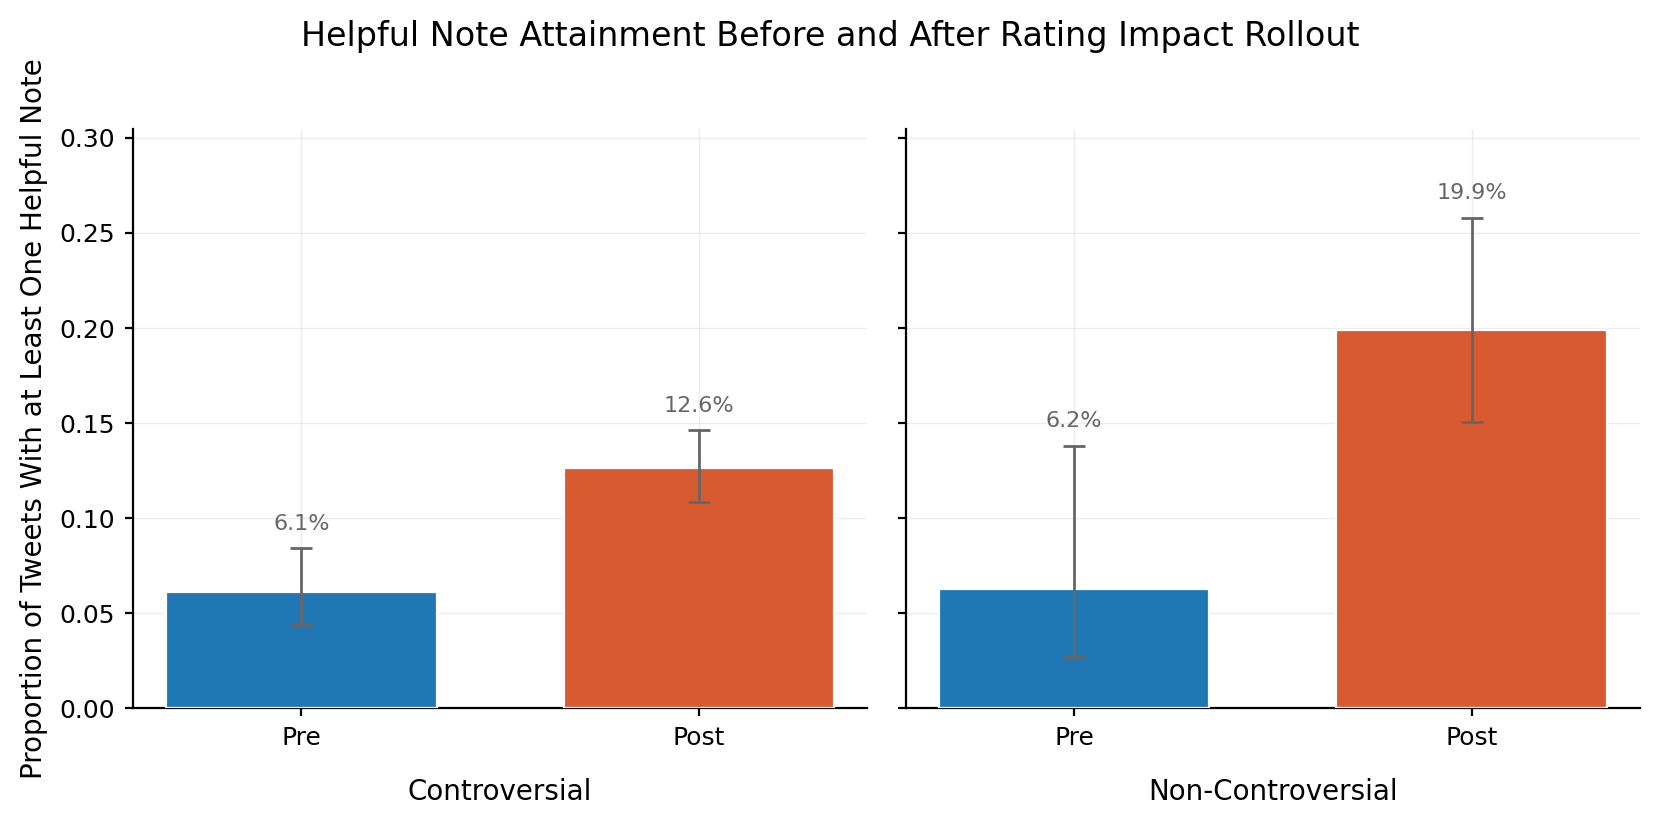

In [34]:
# --- utility: Wilson CI for aggregated counts ------------------------------
def wilson_ci_agg(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + (z**2) / (2*n)) / denom
    margin = (z * np.sqrt((phat*(1-phat)/n) + (z**2)/(4*n**2))) / denom
    return center - margin, center + margin


def plot_pre_post_helpful_difference(
    df_weekly: pd.DataFrame,
    cutoff_date: str = "2022-10-01",
    categories=("Controversial", "Non-Controversial"),
    period_labels=("Pre", "Post"),
    colors=None,
    title="Helpful Note Attainment Before and After Rating Impact Rollout",
    path="/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/",
    suffix: str = "",
):
    if colors is None:
        colors = [_C_BLUE, _C_ORANGE]

    cutoff = pd.to_datetime(cutoff_date)
    df = df_weekly.copy()
    df["week_dt"] = pd.to_datetime(df["week_dt"])
    df = df.sort_values("week_dt")
    df["period"] = np.where(df["week_dt"] < cutoff, "Pre", "Post")

    rows = []
    for cat in categories:
        dcol = f"denominator_tweets_{cat}"
        hcol = f"helpful_{cat}"
        if dcol not in df.columns or hcol not in df.columns:
            raise KeyError(f"Expected columns '{dcol}' and '{hcol}' not found in dataframe.")

        for period in period_labels:
            g = df[df["period"] == period]
            n = np.nansum(g[dcol].values)
            k = np.nansum(g[hcol].values)
            p = (k / n) if n > 0 else np.nan
            lo, hi = wilson_ci_agg(k, n)
            rows.append({
                "category": cat,
                "period": period,
                "k_helpful": k,
                "n_den": n,
                "prop_helpful": p,
                "ci_lo": lo,
                "ci_hi": hi,
            })
    agg = pd.DataFrame(rows)

    print("\nSummary of mean helpfulness and 95% CI (Wilson):")
    for cat in categories:
        for period in period_labels:
            row = agg[(agg["category"] == cat) & (agg["period"] == period)]
            if not row.empty:
                p = row["prop_helpful"].values[0]
                lo = row["ci_lo"].values[0]
                hi = row["ci_hi"].values[0]
                print(f"{cat:>15} | {period:>4} | mean = {p:.3f}, 95% CI = [{lo:.3f}, {hi:.3f}]")

    apply_publication_style()
    fig, axes = plt.subplots(1, len(categories), figsize=(4.2 * len(categories), 4.0), sharey=True)
    if len(categories) == 1:
        axes = [axes]

    ymax = agg["ci_hi"].max()
    if pd.isna(ymax):
        ymax = agg["prop_helpful"].max()
    ymax = min(1.0, ymax * 1.18)

    for ax, cat in zip(axes, categories):
        sub = agg[agg["category"] == cat].set_index("period").loc[list(period_labels)]
        x = np.arange(len(period_labels))
        y = sub["prop_helpful"].to_numpy(dtype=float)
        yerr = np.vstack([
            y - sub["ci_lo"].to_numpy(dtype=float),
            sub["ci_hi"].to_numpy(dtype=float) - y,
        ])

        ax.bar(
            x,
            y,
            width=0.68,
            color=colors[:len(period_labels)],
            edgecolor="white",
            linewidth=0.8,
            yerr=yerr,
            error_kw=dict(ecolor=_C_ZERO, lw=1.0, capsize=4, capthick=1.0),
            zorder=3,
        )

        for xi, prop, ci_hi in zip(x, y, sub["ci_hi"]):
            ax.text(
                xi,
                ci_hi + ymax * 0.025,
                f"{prop:.1%}",
                ha="center",
                va="bottom",
                fontsize=_FONT_ANNOT,
                color=_C_ZERO,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(period_labels, fontsize=_FONT_TICK)
        ax.set_xlabel(cat, fontsize=_FONT_LABEL, labelpad=10)
        ax.set_ylim(0, ymax)
        _setup_ax(ax)

    axes[0].set_ylabel("Proportion of Tweets With at Least One Helpful Note", fontsize=_FONT_LABEL)
    _finalize(fig, axes, title=title)

    filename = f"{title.replace(' ', '_').replace(':', '')}{('_' + suffix) if suffix else ''}.png"
    fig.savefig(os.path.join(path, filename), dpi=300, bbox_inches="tight")
    plt.show()


plot_pre_post_helpful_difference(
    p_df[(p_df["week_dt"] < "2023-03-01") & (p_df["week_dt"] > "2022-06-01")],
    cutoff_date="2022-10-01",
    suffix="managed",
)

# Main Text Table 1

In [35]:
def _prepare_long_from_panel(panel_df, treated="Non-Controversial", control="Controversial",
                             min_n=30, use_jeffreys=True):
    """
    Returns long df with one row per (week, topic): week_dt, topic_type, prop, n_raw.
    prop uses Jeffreys smoothing for stability; n_raw is the raw denominator for weights.
    """
    df = panel_df.copy()
    df["week_dt"] = pd.to_datetime(df["week_dt"])

    out = []
    for topic in (treated, control):
        k_raw = df[f"helpful_{topic}"].astype(float)
        n_raw = df[f"denominator_tweets_{topic}"].astype(float)

        # Smoothed proportion for stability, but keep RAW n for weights
        if use_jeffreys:
            k = k_raw + 0.5
            n = n_raw + 1.0
        else:
            k, n = k_raw, n_raw

        prop = np.where(n_raw > 0, k / n, np.nan)
        keep = (n_raw >= min_n) & np.isfinite(prop)

        out.append(pd.DataFrame({
            "week_dt": df["week_dt"],
            "topic_type": topic,
            "prop": pd.Series(prop).where(keep),
            "n_raw": n_raw.where(keep)
        }))

    long_df = pd.concat(out, ignore_index=True).dropna(subset=["prop", "n_raw"])
    return long_df


def _weekly_diff_series(long_df, treated, control, weight_mode="min"):
    """
    Balanced weekly difference series:
      diff_t = prop_treated_t - prop_control_t
      w_t    = min(n_treated_t, n_control_t) or sum(...), per weight_mode.
    """
    wide = long_df.pivot(index="week_dt", columns="topic_type", values=["prop", "n_raw"])
    props = wide["prop"]
    ns = wide["n_raw"]

    if treated not in props or control not in props:
        raise ValueError("After filtering, one of the topics is missing. Check names and min_n.")

    # Keep only weeks where both are observed
    diff = (props[treated] - props[control]).dropna()
    n_t = ns[treated].reindex(diff.index)
    n_c = ns[control].reindex(diff.index)

    if weight_mode == "sum":
        w = (n_t + n_c).astype(float)
    else:  # default "min"
        w = np.minimum(n_t, n_c).astype(float)

    w = w.clip(lower=1.0)

    series = pd.DataFrame({"diff": diff.astype(float), "w": w.astype(float)})
    series.index.name = "week_dt"
    return series


def _fit_window(y, w, is_post, hac_maxlags=4):
    """
    WLS diff-in-means (pre vs post) with HAC standard errors.
    y, w, is_post can be numpy arrays or pandas Series.
    """
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)
    is_post = np.asarray(is_post, dtype=float)

    X = sm.add_constant(is_post)
    fit = sm.WLS(y, X, weights=w).fit(cov_type="HAC", cov_kwds={"maxlags": hac_maxlags})

    est = float(fit.params[1])
    se = float(fit.bse[1])
    p = float(fit.pvalues[1])
    z = 1.96
    ci = (est - z * se, est + z * se)
    return {"est": est, "se": se, "ci": ci, "p": p}


def did_windows_v2(panel_df,
                   change_date="2022-12-15",
                   treated="Non-Controversial",
                   control="Controversial",
                   pre_weeks=8,
                   short_post_weeks=8,
                   medium_post_weeks=(9, 26),
                   min_n=30,
                   use_jeffreys=True,
                   weight_mode="min",
                   hac_maxlags=4):
    """
    Short- and medium-run DiD on weekly helpfulness differences.
    Returns dict with 'short', 'medium', 'series', and 'meta'.
    """
    # Build balanced weekly diff series
    long_df = _prepare_long_from_panel(panel_df, treated, control, min_n, use_jeffreys)
    series = _weekly_diff_series(long_df, treated, control, weight_mode)
    series = series.sort_index()
    change_dt = pd.to_datetime(change_date)

    weeks = series.index

    # Pre window: last `pre_weeks` weeks strictly before the change
    pre_weeks_idx = weeks[weeks < change_dt]
    pre_weeks_idx = pre_weeks_idx[-pre_weeks:]  # if fewer exist, we take all available

    # Short post: from change_dt inclusive, take the next `short_post_weeks` observed weeks
    short_post_all = weeks[weeks >= change_dt]
    short_idx = short_post_all[:short_post_weeks]

    # Medium post: (lo, hi) weeks after change (inclusive)
    m_lo, m_hi = medium_post_weeks
    med_start = change_dt + pd.Timedelta(weeks=m_lo)
    med_end = change_dt + pd.Timedelta(weeks=m_hi)
    med_idx = weeks[(weeks >= med_start) & (weeks <= med_end)]

    def _run_window(idx_post):
        # aligned boolean masks (as Series) to avoid reindex warnings
        pre_mask = pd.Series(series.index.isin(pre_weeks_idx), index=series.index)
        post_mask = pd.Series(series.index.isin(idx_post), index=series.index)
        keep = pre_mask | post_mask

        y = series.loc[keep, "diff"]
        w = series.loc[keep, "w"]
        is_post = post_mask.loc[keep]

        # guard rails
        if y.size < 4 or is_post.sum() == 0 or (~is_post).sum() == 0:
            return {
                "est": np.nan, "se": np.nan, "ci": (np.nan, np.nan), "p": np.nan,
                "n_pre": int((~is_post).sum()), "n_post": int(is_post.sum()),
                "weeks_pre": list(pre_weeks_idx.astype(str)),
                "weeks_post": list(pd.DatetimeIndex(idx_post).astype(str)),
            }

        out = _fit_window(y.to_numpy(), w.to_numpy(), is_post.to_numpy(), hac_maxlags=hac_maxlags)
        out.update({
            "n_pre": int((~is_post).sum()),
            "n_post": int(is_post.sum()),
            "weeks_pre": list(pre_weeks_idx.astype(str)),
            "weeks_post": list(pd.DatetimeIndex(idx_post).astype(str)),
        })
        return out

    short_res = _run_window(short_idx)
    medium_res = _run_window(med_idx)

    return {
        "short": short_res,
        "medium": medium_res,
        "series": series.reset_index(),  # columns: week_dt, diff, w
        "meta": {
            "change_date": str(pd.to_datetime(change_date).date()),
            "pre_weeks": pre_weeks,
            "short_post_weeks": short_post_weeks,
            "medium_post_weeks": medium_post_weeks,
            "min_n": min_n,
            "weight_mode": weight_mode,
            "use_jeffreys": use_jeffreys,
            "hac_maxlags": hac_maxlags,
            "treated": treated,
            "control": control,
        },
    }


In [36]:
res = did_windows_v2(
    p_df,
    change_date="2022-10-01",
    treated="Non-Controversial",
    control="Controversial",
    pre_weeks=12,
    short_post_weeks=12,
    medium_post_weeks=(13, 26),
    min_n=5,                 
    use_jeffreys=True,
    weight_mode="min",
    hac_maxlags=4
)

print(res["short"])    # dict: est, se, ci, p, n_pre, n_post, weeks_pre, weeks_post
print(res["medium"])   # same for the medium window
res["series"].head() 

{'est': 0.08821449008585106, 'se': 0.03725024523847778, 'ci': (0.01520400941843461, 0.1612249707532675), 'p': 0.01787686876355735, 'n_pre': 12, 'n_post': 12, 'weeks_pre': ['2022-04-03', '2022-05-08', '2022-05-15', '2022-05-22', '2022-05-29', '2022-06-05', '2022-06-12', '2022-06-26', '2022-07-24', '2022-09-04', '2022-09-11', '2022-09-25'], 'weeks_post': ['2022-10-02', '2022-10-09', '2022-10-16', '2022-11-06', '2022-11-13', '2022-11-20', '2022-11-27', '2022-12-04', '2022-12-11', '2022-12-18', '2022-12-25', '2023-01-01']}
{'est': 0.11849523077509254, 'se': 0.0446140633877791, 'ci': (0.0310516665350455, 0.20593879501513956), 'p': 0.007907215109352845, 'n_pre': 12, 'n_post': 12, 'weeks_pre': ['2022-04-03', '2022-05-08', '2022-05-15', '2022-05-22', '2022-05-29', '2022-06-05', '2022-06-12', '2022-06-26', '2022-07-24', '2022-09-04', '2022-09-11', '2022-09-25'], 'weeks_post': ['2023-01-01', '2023-01-08', '2023-01-15', '2023-01-22', '2023-01-29', '2023-02-12', '2023-02-19', '2023-02-26', '2023-0

,week_dt,diff,w
0,2021-01-31,-0.000880,7.0
1,2021-02-07,0.033088,7.0
2,2021-02-14,0.069444,5.0
3,2021-02-21,0.064935,10.0
4,2021-04-04,0.056548,6.0


# Main Text Table 2

In [37]:
ratings_filtered = ratings_df[ratings_df['raterParticipantId'].isin(legacy_users)]

In [38]:
def merge_factors_safe(ratings_df, note_df, rater_df, in_sample=False):
    """
    Attach most recent rater and note factors to each rating row.

    If in_sample=False, factors must come from a strictly previous week.
    If in_sample=True, same-week factors are allowed.

    The helper accepts factor dataframes that use either `week_dt` or
    `createdAtWeek` as the weekly timestamp column.
    """
    ratings = ratings_df.copy()
    note = note_df.copy()
    rater = rater_df.copy()

    def _coerce_id(series):
        # Normalize numeric ids that may have been read as floats, e.g. 123.0.
        numeric = pd.to_numeric(series, errors="coerce")
        out = series.astype("string")
        mask = numeric.notna()
        out.loc[mask] = numeric.loc[mask].astype("Int64").astype("string")
        return out

    def _ensure_week_col(df, name):
        df = df.copy()
        if "week_dt" in df.columns:
            df["week_dt"] = pd.to_datetime(df["week_dt"]).dt.normalize()
        elif "createdAtWeek" in df.columns:
            df["week_dt"] = pd.to_datetime(df["createdAtWeek"]).dt.normalize()
        else:
            raise ValueError(f"{name} must include either 'week_dt' or 'createdAtWeek'.")
        return df

    ratings["noteId"] = _coerce_id(ratings["noteId"])
    ratings["raterParticipantId"] = ratings["raterParticipantId"].astype("string")
    note["noteId"] = _coerce_id(note["noteId"])
    rater["raterParticipantId"] = rater["raterParticipantId"].astype("string")

    ratings["createdAtDate"] = pd.to_datetime(ratings["createdAtMillis"], unit="ms")
    ratings["week_dt"] = ratings["createdAtDate"].dt.to_period("W").dt.start_time.dt.normalize()
    note = _ensure_week_col(note, "note_df")
    rater = _ensure_week_col(rater, "rater_df")

    # `merge_asof` requires the left/right frames to be globally sorted by the time key.
    ratings_note_sorted = (
        ratings
        .sort_values(["week_dt", "noteId"])
        .reset_index()
        .rename(columns={"index": "__orig_index"})
    )
    ratings_rater_sorted = (
        ratings
        .sort_values(["week_dt", "raterParticipantId"])
        .reset_index()
        .rename(columns={"index": "__orig_index"})
    )
    note_sorted = note.sort_values(["week_dt", "noteId"]).reset_index(drop=True)
    rater_sorted = rater.sort_values(["week_dt", "raterParticipantId"]).reset_index(drop=True)

    note_merge = pd.merge_asof(
        ratings_note_sorted,
        note_sorted[["noteId", "week_dt", "noteFactor1", "noteIntercept"]],
        by="noteId",
        left_on="week_dt",
        right_on="week_dt",
        direction="backward",
        allow_exact_matches=in_sample,
    ).rename(columns={"week_dt": "note_factor_week"})

    rater_merge = pd.merge_asof(
        ratings_rater_sorted,
        rater_sorted[["raterParticipantId", "week_dt", "raterFactor1", "raterIntercept"]],
        by="raterParticipantId",
        left_on="week_dt",
        right_on="week_dt",
        direction="backward",
        allow_exact_matches=in_sample,
    ).rename(columns={"week_dt": "rater_factor_week"})

    combined = ratings.reset_index().rename(columns={"index": "__orig_index"}).set_index("__orig_index")
    combined = combined.join(
        note_merge.set_index("__orig_index")[["note_factor_week", "noteFactor1", "noteIntercept"]],
        how="left",
    )
    combined = combined.join(
        rater_merge.set_index("__orig_index")[["rater_factor_week", "raterFactor1", "raterIntercept"]],
        how="left",
    )

    combined["helpful_binary"] = np.where(
        combined["helpfulnessLevel"] == "HELPFUL", 1.0,
        np.where(combined["helpfulnessLevel"] == "NOT_HELPFUL", 0.0, np.nan),
    )

    combined = combined.dropna(subset=["noteFactor1", "raterFactor1", "helpful_binary"]).copy()
    combined["vote_label"] = combined["helpful_binary"].map({1.0: "Helpful", 0.0: "Not Helpful"})
    return combined.reset_index(drop=True)


In [39]:
def compute_pre_estimate(df):
    df = df.copy()
    df['pre_estimate_mf'] = df['noteIntercept'] + df['raterIntercept'] + df['noteFactor1']*df['raterFactor1']

    return df

def compute_global_unweighted_means(df):
    df = compute_pre_estimate(df.copy())
    result_df = (
        df.groupby('week_dt', sort=True)
          .apply(lambda x: np.mean(x['helpful_binary'] - x['pre_estimate_mf']))
          .reset_index(name='mu')
    )
    return result_df


def compute_matrix_factorization_estimates(df, in_sample=True):
    '''
    Note: if in_sample = False, then use the most recent *previous* estimate for the global mean
    '''
    df = df.copy()
    mu_df = compute_global_unweighted_means(df)
    
    # Compute MF pre-estimate
    df['pre_estimate_mf'] = df['noteIntercept'] + df['raterIntercept'] + df['noteFactor1']*df['raterFactor1']

    if in_sample:
        # use same-week mu
        df = df.merge(mu_df, on='week_dt', how='left')
    else:
        # use previous week's mu
        mu_df = mu_df.sort_values('week_dt').copy()
        mu_df['mu'] = mu_df['mu'].shift(1)   # shift one row down
        df = df.merge(mu_df, on='week_dt', how='left')

        # handle the first week (no previous mu available)
        df['mu'] = df['mu'].fillna(mu_df['mu'].mean())

    # Compute MF estimates by adding mu back
    df['estimate_mf'] = df['mu'] + df['pre_estimate_mf']

    return df

In [40]:
df_in_sample = merge_factors_safe(ratings_df, note_df_full_2025, rater_df_2025, in_sample=True)
df_out_of_sample = merge_factors_safe(ratings_df, note_df_full_2025, rater_df_2025, in_sample=False)
display(df_in_sample.shape, df_out_of_sample.shape)

(14177, 14)

(2229, 14)

In [41]:
# these are the two relevant dataframes for matrix factorization in-sample and one week ahead estimates
df_in_sample_mf = compute_matrix_factorization_estimates(df_in_sample, in_sample=True)
df_out_of_sample_mf = compute_matrix_factorization_estimates(df_out_of_sample, in_sample=False)

/tmp/ipykernel_1110240/3233219998.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_1110240/3233219998.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [42]:
df_in_sample_mf['squared_residual_in_sample'] = (df_in_sample_mf['estimate_mf'] - df_in_sample_mf['helpful_binary'])**2
df_out_of_sample_mf['squared_residual_oos'] = (df_out_of_sample_mf['estimate_mf'] - df_out_of_sample_mf['helpful_binary'])**2

In [43]:
def avg_mse_pre_post(df, cutoff, months, date_col="week_dt", mse_col="mse"):
    cutoff = pd.to_datetime(cutoff)
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col])

    pre  = d[(d[date_col] >= cutoff - pd.DateOffset(months=months)) & (d[date_col] < cutoff)][mse_col].dropna()
    post = d[(d[date_col] >= cutoff) & (d[date_col] < cutoff + pd.DateOffset(months=months))][mse_col].dropna()

    pre_mean, post_mean = pre.mean(), post.mean()
    pre_se  = pre.std(ddof=1) / np.sqrt(len(pre))
    post_se = post.std(ddof=1) / np.sqrt(len(post))

    pre_ci  = (pre_mean  - 1.96*pre_se,  pre_mean  + 1.96*pre_se)
    post_ci = (post_mean - 1.96*post_se, post_mean + 1.96*post_se)

    return pre_mean, pre_ci, post_mean, post_ci


In [44]:
pre_mean, pre_ci, post_mean, post_ci = avg_mse_pre_post(
    df_in_sample_mf, "2022-10-01", 3,
    mse_col="squared_residual_in_sample"
)


In [45]:
print(pre_mean, pre_ci, post_mean, post_ci)

0.048752172599057696 (np.float64(0.03266704287024469), np.float64(0.0648373023278707)) 0.10568706896191987 (np.float64(0.10052730874661477), np.float64(0.11084682917722498))


In [46]:
pre_mean_oos, pre_ci_oos, post_mean_oos, post_ci_oos = avg_mse_pre_post(
    df_out_of_sample_mf, "2022-10-01", 3,
    mse_col="squared_residual_oos"
)


In [47]:
print(pre_mean_oos, pre_ci_oos, post_mean_oos, post_ci_oos)

0.09270713817283788 (np.float64(0.060041049054931114), np.float64(0.12537322729074463)) 0.16341599370289214 (np.float64(0.14286801861938872), np.float64(0.18396396878639557))


# Main Text Figure 4

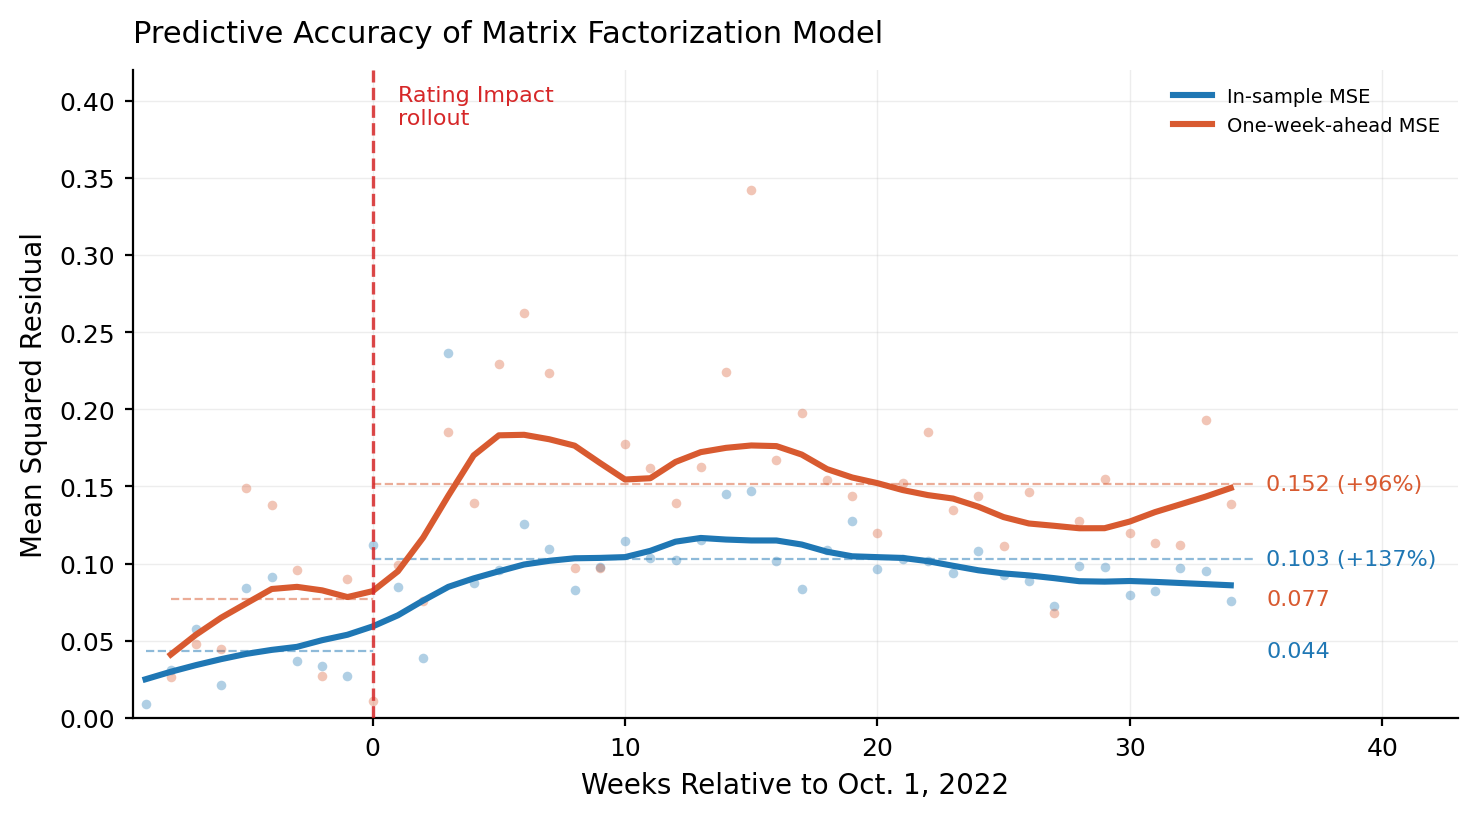

In [66]:
def plot_mf_residuals_by_week(
    df_in_sample_mf,
    df_out_of_sample_mf,
    cutoff_date="2022-10-01",
    frac_lowess=0.25,
    save_path="/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/mf_residuals_by_week_2025.png",
    title="Predictive Accuracy of Matrix Factorization Model",
):
    cutoff = pd.to_datetime(cutoff_date)

    in_week = (
        df_in_sample_mf
        .groupby("week_dt")["squared_residual_in_sample"]
        .agg(["mean", "std", "count"])
        .sort_index()
    )
    in_week.index = pd.to_datetime(in_week.index)
    in_week["week_rel"] = ((in_week.index - cutoff).days / 7).round().astype(int)

    oos_week = (
        df_out_of_sample_mf
        .groupby("week_dt")["squared_residual_oos"]
        .agg(["mean", "std", "count"])
        .sort_index()
    )
    oos_week.index = pd.to_datetime(oos_week.index)
    oos_week["week_rel"] = ((oos_week.index - cutoff).days / 7).round().astype(int)

    apply_publication_style()
    fig, ax = plt.subplots(figsize=(7.5, 4.2))

    series_specs = [
        (in_week, "In-sample MSE", _C_BLUE),
        (oos_week, "One-week-ahead MSE", _C_ORANGE),
    ]

    for week_df, label, color in series_specs:
        x = week_df["week_rel"].to_numpy(dtype=float)
        y = week_df["mean"].to_numpy(dtype=float)

        ax.scatter(x, y, color=color, alpha=0.35, s=12, linewidths=0, zorder=2)
        sm = lowess(y, x, frac=frac_lowess, return_sorted=True)
        ax.plot(sm[:, 0], sm[:, 1], color=color, linewidth=2.2, label=label, zorder=4)

        pre = week_df[week_df["week_rel"] < 0]["mean"]
        post = week_df[week_df["week_rel"] >= 0]["mean"]
        pre_mean = pre.mean()
        post_mean = post.mean()
        pct_change = ((post_mean / pre_mean) - 1) * 100

        ax.hlines(pre_mean, xmin=x.min(), xmax=0, color=color, linestyle="--", linewidth=0.8, alpha=0.5, zorder=2)
        ax.hlines(post_mean, xmin=0, xmax=x.max() + 1, color=color, linestyle="--", linewidth=0.8, alpha=0.5, zorder=2)
        ax.text(x.max() + 1.4, post_mean, f"{post_mean:.3f} ({pct_change:+.0f}%)", color=color, fontsize=_FONT_ANNOT, va="center", ha="left")
        ax.text(x.max() + 1.4, pre_mean, f"{pre_mean:.3f}", color=color, fontsize=_FONT_ANNOT, va="center", ha="left")

    ax.axvline(0, color=_C_EVENT, linewidth=1.2, linestyle="--", alpha=0.85, zorder=5)
    ax.text(1, 0.41, "Rating Impact\nrollout", color=_C_EVENT, fontsize=_FONT_ANNOT, va="top", ha="left")

    x_min = min(in_week["week_rel"].min(), oos_week["week_rel"].min())
    x_max = max(in_week["week_rel"].max(), oos_week["week_rel"].max())
    ax.set_xlim(x_min - 0.5, x_max + 9)
    ax.set_ylim(0, 0.42)
    ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="upper right")

    _setup_ax(ax)
    _finalize(
        fig,
        ax,
        xlabel="Weeks Relative to Oct. 1, 2022",
        ylabel="Mean Squared Residual",
        title=title,
        save_path=save_path,
    )


plot_mf_residuals_by_week(
    df_in_sample_mf,
    df_out_of_sample_mf,
    cutoff_date="2022-10-01",
    save_path="/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/mf_residuals_by_week_2025.png",
)

# Main Text Figure 5

In [50]:
# use the output from the two stage experiments
note_params_stage1 = pd.read_csv('/accounts/projects/jchayes/commnotes/analysis/two_stage/output_final/note_params_weekly_stage1_20251112_174832.csv')
rater_params_stage1 = pd.read_csv('/accounts/projects/jchayes/commnotes/analysis/two_stage/output_final/rater_params_weekly_stage1_20251112_174832.csv')
note_params_stage2 = pd.read_csv('/accounts/projects/jchayes/commnotes/analysis/two_stage/output_final/note_params_weekly_stage2_20251112_174832.csv')
rater_params_stage2 = pd.read_csv('/accounts/projects/jchayes/commnotes/analysis/two_stage/output_final/rater_params_weekly_stage2_20251112_174832.csv')

global_bias_stage1 = pd.read_csv('/accounts/projects/jchayes/commnotes/analysis/two_stage/output_final/global_bias_weekly_stage1_20251112_174832.csv')
global_bias_stage2 = pd.read_csv('/accounts/projects/jchayes/commnotes/analysis/two_stage/output_final/global_bias_weekly_stage2_20251112_174832.csv')

In [51]:
ratings_df = read_ratings_from_directory(RATINGS_DIR, start_date_str="2023-01-01", end_date_str="2024-06-01")

Found 16 total rating files. Processing them in chunks to filter by date.


Reading ratings: 100%|██████████| 16/16 [05:32<00:00, 20.75s/it]


In [52]:
# Convert helpfulnessLevel to numeric helpfulNum
ratings_df['helpfulNum'] = None
ratings_df.loc[ratings_df['helpfulnessLevel'] == 'HELPFUL', 'helpfulNum'] = 1.0
ratings_df.loc[ratings_df['helpfulnessLevel'] == 'SOMEWHAT_HELPFUL', 'helpfulNum'] = 0.5
ratings_df.loc[ratings_df['helpfulnessLevel'] == 'NOT_HELPFUL', 'helpfulNum'] = 0.0

# Drop rows where helpfulNum is NaN (ratings with no helpfulness level)
ratings_df = ratings_df[ratings_df['helpfulNum'].notna()]
ratings_df['helpfulNum'] = ratings_df['helpfulNum'].astype(float)

# Match the weekly timestamp construction used in analyze_output.ipynb
ratings_df['createdAtDate'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms').dt.normalize()
ratings_df['createdAtWeek'] = ratings_df['createdAtDate'] - pd.to_timedelta(ratings_df['createdAtDate'].dt.dayofweek, unit='d')
ratings_df = ratings_df.sort_values(by='createdAtWeek')

In [53]:
def merge_factors(ratings_df, note_df, rater_df):
    """
    Merge the most recent note and rater parameters for each rating using merge_asof.
    Uses factors from weeks strictly before the rating week.

    The returned dataframe keeps:
    - createdAtWeek: the rating week
    - noteFactorWeek: the week of the note parameters used
    - raterFactorWeek: the week of the rater parameters used
    """
    ratings_df = ratings_df.copy()
    ratings_df['createdAtWeek'] = pd.to_datetime(ratings_df['createdAtWeek'])
    note_df = note_df.copy()
    note_df['createdAtWeek'] = pd.to_datetime(note_df['createdAtWeek'])
    rater_df = rater_df.copy()
    rater_df['createdAtWeek'] = pd.to_datetime(rater_df['createdAtWeek'])

    ratings_df['noteId'] = ratings_df['noteId'].astype(str)
    ratings_df['raterParticipantId'] = ratings_df['raterParticipantId'].astype(str)
    note_df['noteId'] = note_df['noteId'].astype(str)
    rater_df['raterParticipantId'] = rater_df['raterParticipantId'].astype(str)

    note_df = note_df.rename(columns={'createdAtWeek': 'noteFactorWeek'})
    rater_df = rater_df.rename(columns={'createdAtWeek': 'raterFactorWeek'})

    ratings_df = ratings_df.sort_values('createdAtWeek')
    note_df = note_df.sort_values('noteFactorWeek')
    rater_df = rater_df.sort_values('raterFactorWeek')

    result = pd.merge_asof(
        ratings_df,
        note_df,
        left_on='createdAtWeek',
        right_on='noteFactorWeek',
        by='noteId',
        direction='backward',
        allow_exact_matches=False,
        suffixes=('', '_note')
    )

    result = pd.merge_asof(
        result.sort_values('createdAtWeek'),
        rater_df,
        left_on='createdAtWeek',
        right_on='raterFactorWeek',
        by='raterParticipantId',
        direction='backward',
        allow_exact_matches=False,
        suffixes=('', '_rater')
    )

    return result


In [65]:
merged_df1 = merge_factors(ratings_df, note_params_stage1, rater_params_stage1)
merged_df2 = merge_factors(ratings_df, note_params_stage2, rater_params_stage2)

In [68]:
merged_df1 = merged_df1.dropna()
merged_df2 = merged_df2.dropna()

In [69]:
merged_df1.head()

,noteId,raterParticipantId,createdAtMillis,helpfulnessLevel,helpfulNum,createdAtDate,createdAtWeek,noteIndex,noteFactor1,noteIntercept,noteFactorWeek,raterIndex,raterFactor1,raterIntercept,raterFactorWeek
356466,1667278065292959749,1D6BCF3EC5BD185718B3B9C72EDCB03A3CA0446941D34D...,1686612689721,NOT_HELPFUL,0.0,2023-06-12,2023-06-12,824.0,0.587052,0.176303,2023-06-05,2313.0,-0.827578,0.195794,2023-06-05
356470,1667344177665916928,1D6BCF3EC5BD185718B3B9C72EDCB03A3CA0446941D34D...,1686612641257,HELPFUL,1.0,2023-06-12,2023-06-12,4733.0,-0.640341,0.049465,2023-06-05,2313.0,-0.827578,0.195794,2023-06-05
356492,1667195987603910656,1D6BCF3EC5BD185718B3B9C72EDCB03A3CA0446941D34D...,1686612649658,HELPFUL,1.0,2023-06-12,2023-06-12,4716.0,-0.628468,0.138231,2023-06-05,2313.0,-0.827578,0.195794,2023-06-05
356536,1667735634134413315,8D993839EA14D05B82960BF29B3A3337BAB1DCB1103318...,1686547854753,NOT_HELPFUL,0.0,2023-06-12,2023-06-12,1001.0,-0.678341,0.142135,2023-06-05,554.0,0.822945,0.152969,2023-06-05
356554,1667793317197643777,1D6BCF3EC5BD185718B3B9C72EDCB03A3CA0446941D34D...,1686532950087,HELPFUL,1.0,2023-06-12,2023-06-12,16861.0,-0.734016,0.116449,2023-06-05,2313.0,-0.827578,0.195794,2023-06-05


In [71]:
global_bias_stage1.head()

,noteFactorWeek,globalBias
0,2023-06-05,0.171799
1,2023-06-12,0.171976
2,2023-06-19,0.172164
3,2023-06-26,0.172093
4,2023-07-03,0.172068


In [72]:
# Merge global bias from the same MF week as the note parameters.
global_bias_stage1 = global_bias_stage1.copy()
global_bias_stage2 = global_bias_stage2.copy()
global_bias_stage1['noteFactorWeek'] = pd.to_datetime(global_bias_stage1['noteFactorWeek'])
global_bias_stage2['noteFactorWeek'] = pd.to_datetime(global_bias_stage2['noteFactorWeek'])

global_bias_stage1 = global_bias_stage1[['noteFactorWeek', 'globalBias']]
global_bias_stage2 = global_bias_stage2[['noteFactorWeek', 'globalBias']]

merged_df1 = merged_df1.merge(global_bias_stage1, on='noteFactorWeek', how='left')
merged_df2 = merged_df2.merge(global_bias_stage2, on='noteFactorWeek', how='left')


In [73]:
merged_df1['helpfulEstimate'] = merged_df1['globalBias'] + merged_df1['raterIntercept'] + merged_df1['noteIntercept'] + merged_df1['raterFactor1'] * merged_df1['noteFactor1']
merged_df2['helpfulEstimate'] = merged_df2['globalBias'] + merged_df2['raterIntercept'] + merged_df2['noteIntercept'] + merged_df2['raterFactor1'] * merged_df2['noteFactor1']


In [74]:
merged_df1['abs_residual'] = np.abs(merged_df1['helpfulNum'] - merged_df1['helpfulEstimate'])
merged_df2['abs_residual'] = np.abs(merged_df2['helpfulNum'] - merged_df2['helpfulEstimate'])


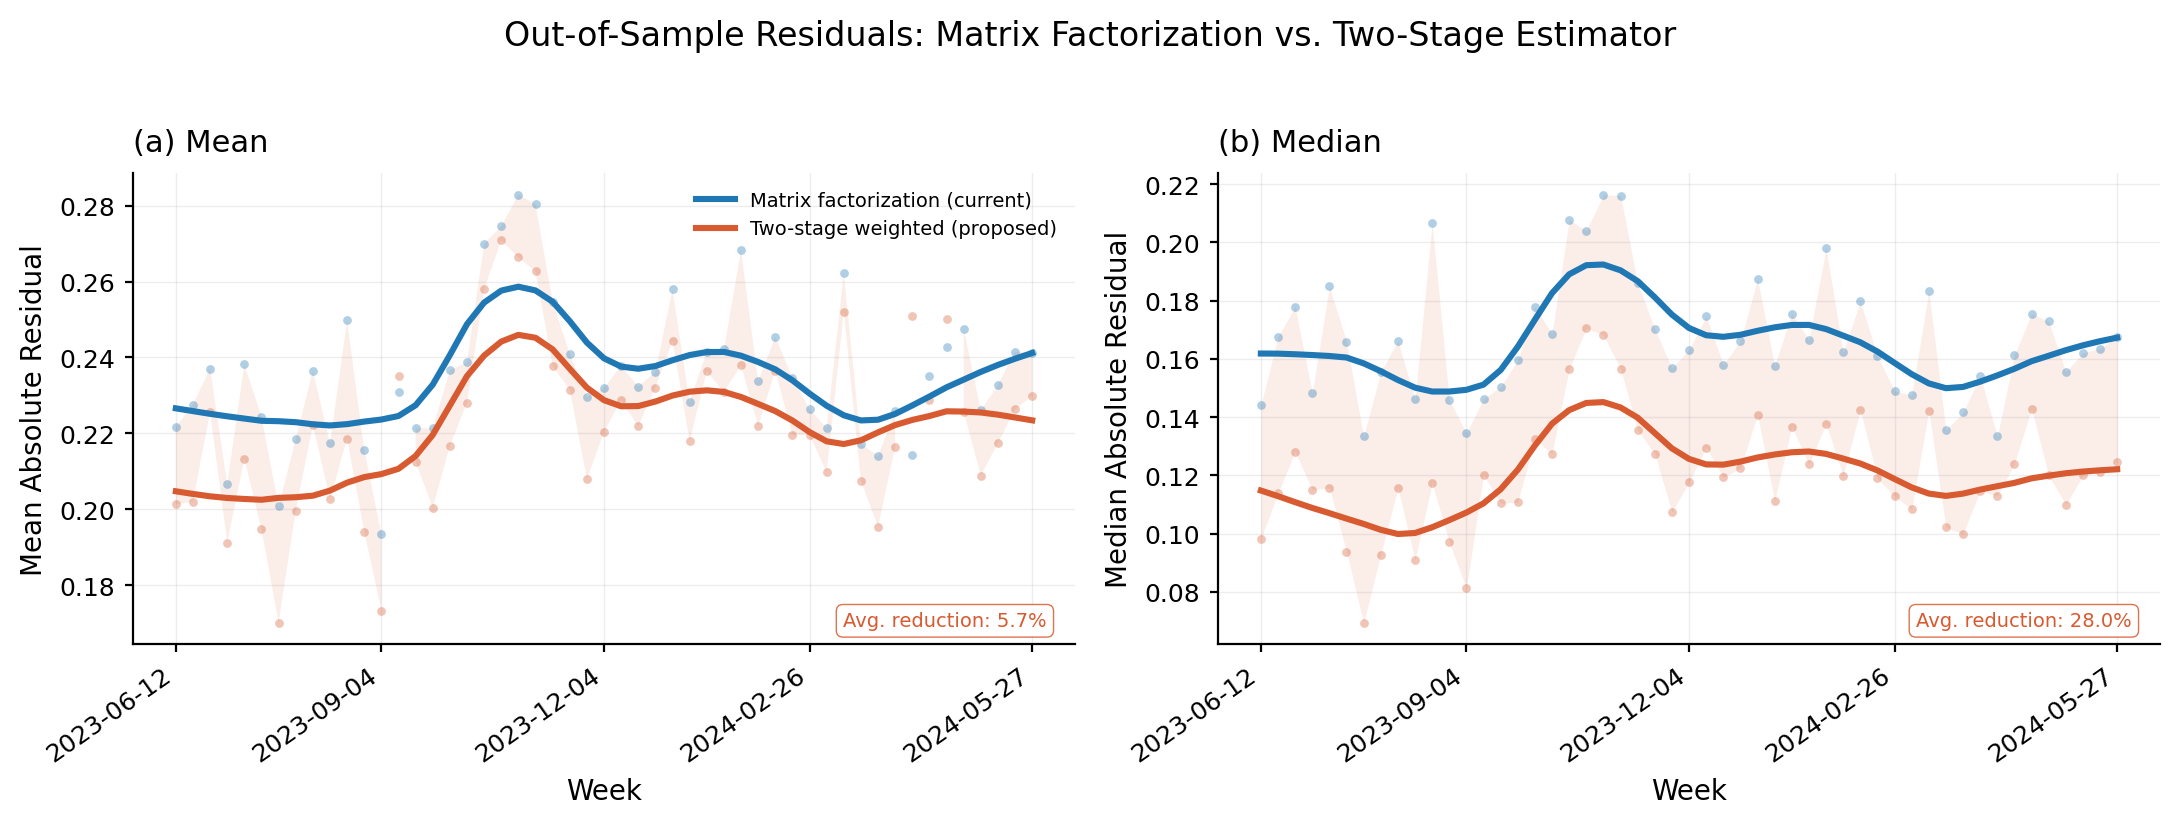

In [77]:
# Compute mean and standard error by week for both dataframes
weekly_stats1 = merged_df1.groupby('createdAtWeek')['abs_residual'].agg(['mean', 'median', 'std', 'count']).reset_index()
weekly_stats1['se'] = weekly_stats1['std'] / np.sqrt(weekly_stats1['count'])

weekly_stats2 = merged_df2.groupby('createdAtWeek')['abs_residual'].agg(['mean', 'median', 'std', 'count']).reset_index()
weekly_stats2['se'] = weekly_stats2['std'] / np.sqrt(weekly_stats2['count'])


def plot_abs_residual_comparison(
    weekly_stats1,
    weekly_stats2,
    metrics=(('mean', 'Mean Absolute Residual', '(a) Mean'), ('median', 'Median Absolute Residual', '(b) Median')),
    save_path='/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/diagnostics/weekly_abs_residuals.png',
    title='Out-of-Sample Residuals: Matrix Factorization vs. Two-Stage Estimator',
):
    d1 = weekly_stats1.copy()
    d2 = weekly_stats2.copy()
    d1['createdAtWeek'] = pd.to_datetime(d1['createdAtWeek'])
    d2['createdAtWeek'] = pd.to_datetime(d2['createdAtWeek'])

    merged = d1.merge(
        d2,
        on='createdAtWeek',
        suffixes=('_mf', '_ts'),
    ).sort_values('createdAtWeek')
    merged['week_num'] = np.arange(len(merged))

    apply_publication_style()
    fig, axes = plt.subplots(1, len(metrics), figsize=(11, 4.0), sharex=True)
    if len(metrics) == 1:
        axes = [axes]

    for ax, (metric, ylabel, panel_title) in zip(axes, metrics):
        x = merged['week_num'].to_numpy(dtype=float)
        y_mf = merged[f'{metric}_mf'].to_numpy(dtype=float)
        y_ts = merged[f'{metric}_ts'].to_numpy(dtype=float)

        ax.fill_between(x, y_mf, y_ts, where=(y_mf >= y_ts), color=_C_ORANGE, alpha=0.10, linewidth=0)
        ax.scatter(x, y_mf, s=10, color=_C_BLUE, alpha=0.35, linewidths=0, zorder=2)
        ax.scatter(x, y_ts, s=10, color=_C_ORANGE, alpha=0.35, linewidths=0, zorder=2)

        if len(x) >= 4:
            sm_mf = lowess(y_mf, x, frac=0.25, return_sorted=True)
            sm_ts = lowess(y_ts, x, frac=0.25, return_sorted=True)
            ax.plot(sm_mf[:, 0], sm_mf[:, 1], color=_C_BLUE, lw=2.2, label='Matrix factorization (current)')
            ax.plot(sm_ts[:, 0], sm_ts[:, 1], color=_C_ORANGE, lw=2.2, label='Two-stage weighted (proposed)')
        else:
            ax.plot(x, y_mf, color=_C_BLUE, lw=2.2, label='Matrix factorization (current)')
            ax.plot(x, y_ts, color=_C_ORANGE, lw=2.2, label='Two-stage weighted (proposed)')

        improvement = np.nanmean((y_mf - y_ts) / y_mf) * 100
        ax.text(
            0.97,
            0.03,
            f'Avg. reduction: {improvement:.1f}%',
            transform=ax.transAxes,
            ha='right',
            va='bottom',
            fontsize=_FONT_LEGEND,
            color=_C_ORANGE,
            bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=_C_ORANGE, lw=0.5, alpha=0.85),
        )

        tick_idx = np.linspace(0, len(merged) - 1, min(5, len(merged)), dtype=int)
        tick_labels = merged.iloc[tick_idx]['createdAtWeek'].dt.strftime('%Y-%m-%d')
        ax.set_xticks(tick_idx)
        ax.set_xticklabels(tick_labels, rotation=35, ha='right')
        ax.set_xlabel('Week')
        ax.set_ylabel(ylabel)
        ax.set_title(panel_title, loc='left', pad=8)
        _setup_ax(ax)

    axes[0].legend(loc='upper right', frameon=False, fontsize=_FONT_LEGEND)
    _finalize(fig, axes, title=title, save_path=save_path)
    return merged


weekly_residual_comparison = plot_abs_residual_comparison(
    weekly_stats1,
    weekly_stats2,
    save_path='/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/weekly_abs_residuals.png',
)

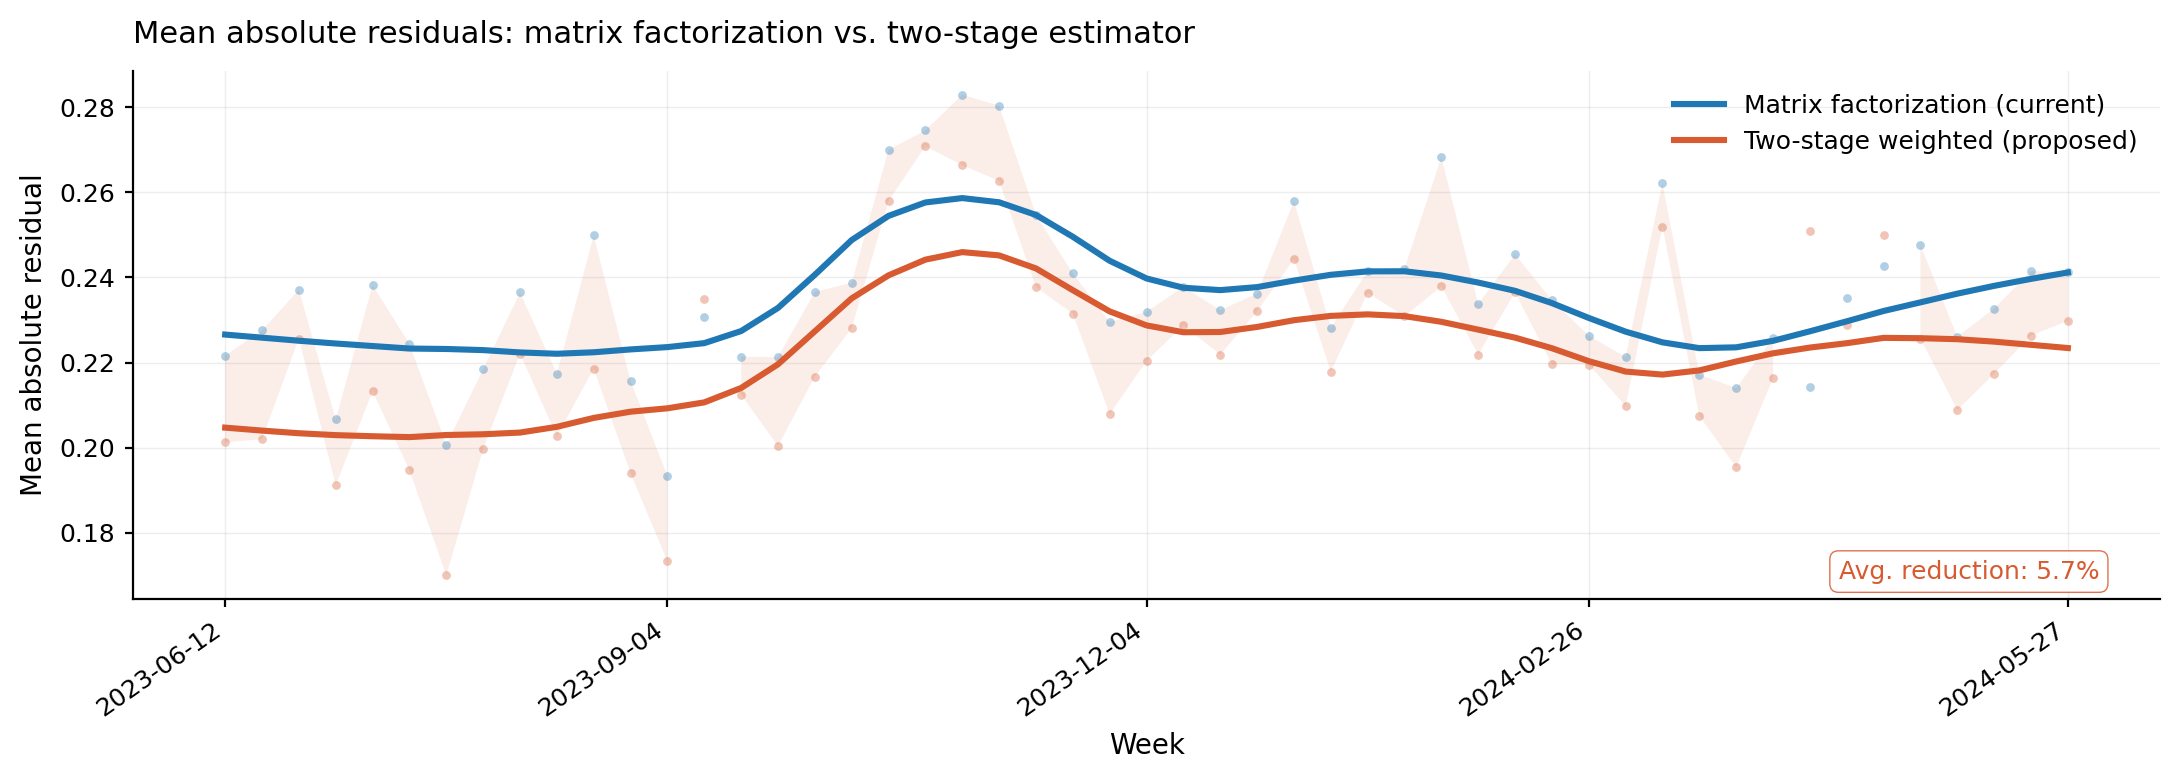

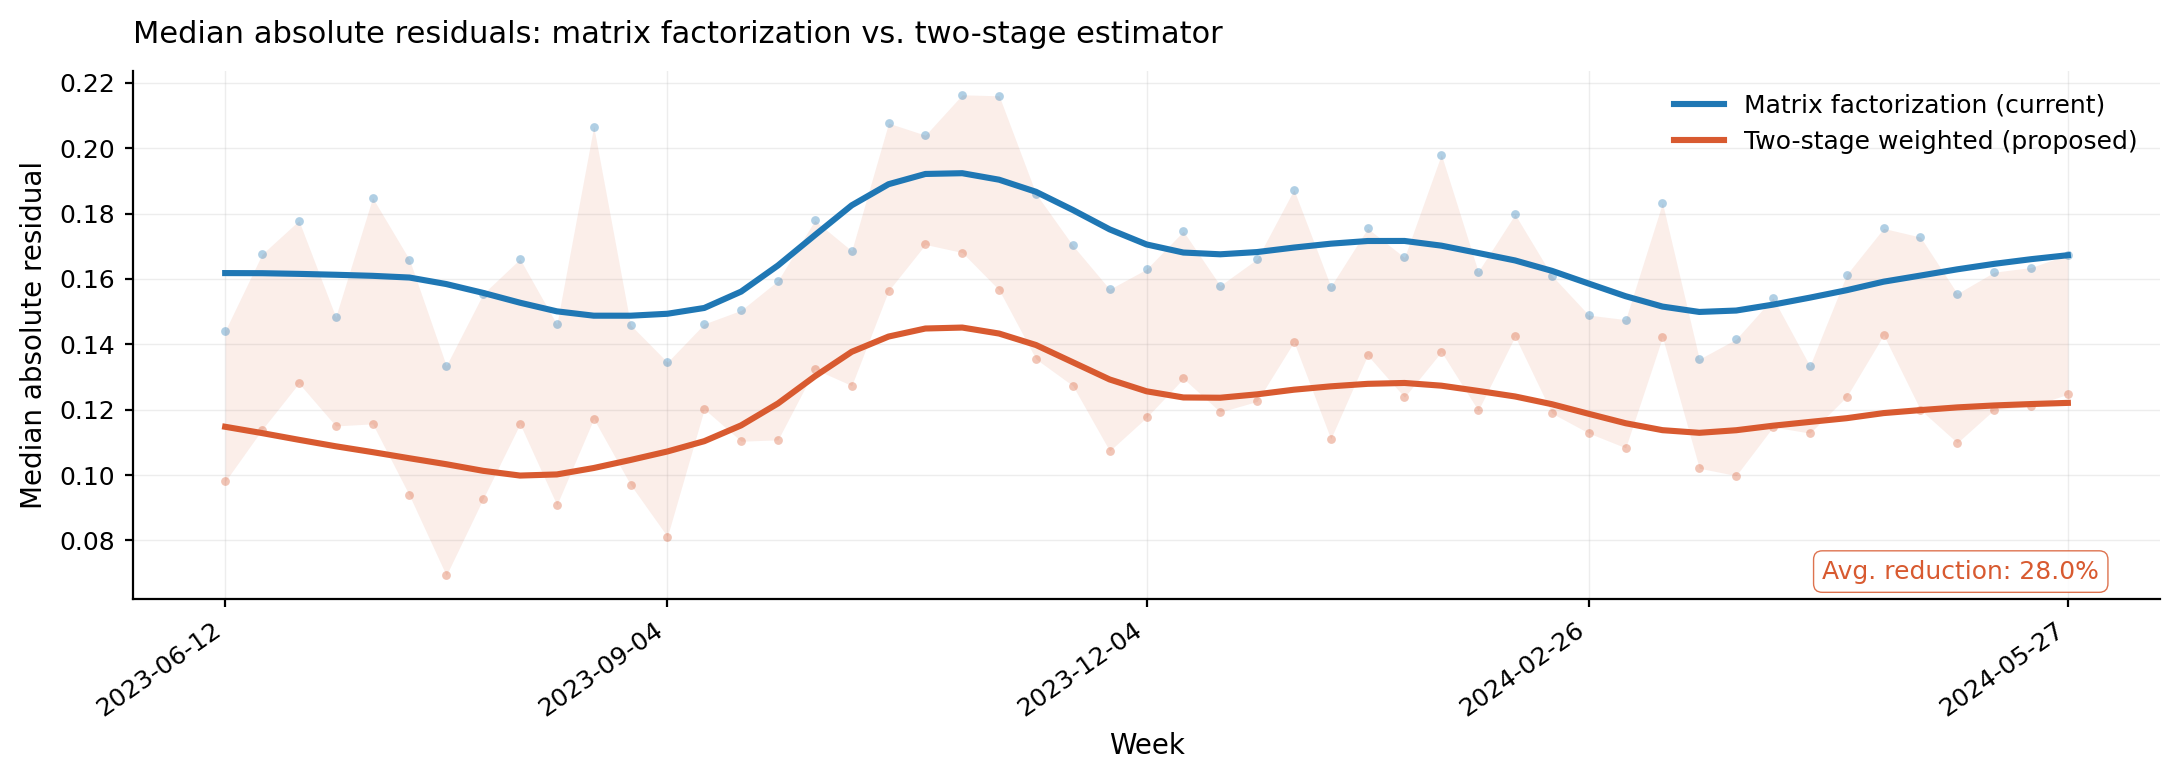

,createdAtWeek,mean_mf,median_mf,std_mf,count_mf,se_mf,mean_ts,median_ts,std_ts,count_ts,se_ts,week_num
0,2023-06-12,0.221644,0.144135,0.219409,1178,0.006393,0.201287,0.098020,0.235538,1178,0.006863,0
1,2023-06-19,0.227582,0.167557,0.199856,1036,0.006209,0.202033,0.113876,0.220139,1036,0.006839,1
2,2023-06-26,0.237083,0.177843,0.211610,1249,0.005988,0.225643,0.128089,0.255923,1249,0.007241,2
3,2023-07-03,0.206659,0.148375,0.198913,1271,0.005579,0.191206,0.115018,0.212046,1271,0.005948,3
4,2023-07-10,0.238195,0.184853,0.206123,935,0.006741,0.213267,0.115666,0.242914,935,0.007944,4
5,2023-07-17,0.224411,0.165929,0.198152,1020,0.006204,0.194749,0.093767,0.321182,1020,0.010057,5
6,2023-07-24,0.200753,0.133450,0.194263,1524,0.004976,0.170041,0.069279,0.241021,1524,0.006174,6
7,2023-07-31,0.218462,0.155443,0.198722,1491,0.005146,0.199679,0.092762,0.253181,1491,0.006557,7
8,2023-08-07,0.236474,0.166095,0.220807,1907,0.005056,0.222121,0.115635,0.269137,1907,0.006163,8
9,2023-08-14,0.217370,0.146093,0.209385,1504,0.005399,0.202693,0.090832,0.267439,1504,0.006896,9


In [ ]:
# Compute mean and standard error by week for both dataframes
weekly_stats1 = merged_df1.groupby('createdAtWeek')['abs_residual'].agg(['mean', 'median', 'std', 'count']).reset_index()
weekly_stats1['se'] = weekly_stats1['std'] / np.sqrt(weekly_stats1['count'])

weekly_stats2 = merged_df2.groupby('createdAtWeek')['abs_residual'].agg(['mean', 'median', 'std', 'count']).reset_index()
weekly_stats2['se'] = weekly_stats2['std'] / np.sqrt(weekly_stats2['count'])

plot_abs_residual_comparison(
    weekly_stats1,
    weekly_stats2,
    metrics=(('mean', 'Mean absolute residual', 'Mean'),),
    save_path='/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/weekly_abs_residuals_mean.png',
    title='Mean absolute residuals: matrix factorization vs. two-stage estimator',
)

plot_abs_residual_comparison(
    weekly_stats1,
    weekly_stats2,
    metrics=(('median', 'Median Absolute Residual', 'Median'),),
    save_path='/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/main/weekly_abs_residuals_median.png',
    title='Median absolute residuals: matrix factorization vs. two-stage estimator',
)